In [23]:
from dotenv import load_dotenv
load_dotenv()

True

In [24]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama import OllamaEmbeddings
from langchain_community.vectorstores import InMemoryVectorStore
from langchain_groq import ChatGroq

from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field

In [25]:
llm = ChatGroq(
    model = "openai/gpt-oss-20b"
)

In [26]:
### Document Load 
loader = PyPDFLoader("../data/medical_report.pdf")
docs = loader.load()

## Split - Chunks 
splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 200)
docs = splitter.split_documents(documents=docs)

## embeddings 
embed = OllamaEmbeddings(
    model = "nomic-embed-text"
)

vector_store = InMemoryVectorStore.from_documents(
    documents=docs, 
    embedding=embed
)

In [27]:
class RagState(BaseModel) : 
    question : str = Field(description="User question")
    documents : list = []
    context : str = Field(description="Context data for user question", default="")
    answer : str = Field(description="Final Answer", default="" )


In [28]:
## question -> retrieve -> context -> generate -> end
def retrieve_node(state : RagState) -> RagState : 
    docs = vector_store.similarity_search(query=state.question)
    state.documents = docs 
    return state

def create_context_node(state : RagState) -> RagState : 
    context = ""
    for doc in state.documents : 
        context += doc.page_content + "\n\n"

    state.context = context
    return state

def generate_node(state : RagState) -> RagState : 
    prompt = f"""
    You are an assistant and provide the answer for the user question based on 
    the provided context . If you don't find the relevant answer, then just say 
    'I don't know'. Context is : {state.context}, 
    Question is : {state.question}
    """

    res = llm.invoke(prompt)
    state.answer = res.content 
    return state

In [29]:
graph = StateGraph(RagState)

graph.add_node("retrieve_node", retrieve_node)
graph.add_node("create_context_node", create_context_node)
graph.add_node("generate_node", generate_node)

graph.add_edge(START, "retrieve_node")
graph.add_edge("retrieve_node", "create_context_node")
graph.add_edge("create_context_node", "generate_node")
graph.add_edge("generate_node", END)

graph = graph.compile()

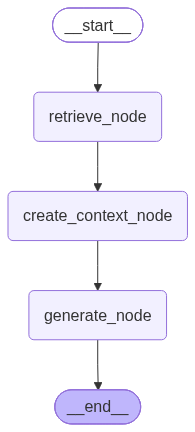

In [30]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [31]:
res = graph.invoke({"question" : "What is the name of the patient?"})

In [32]:
res

{'question': 'What is the name of the patient?',
 'documents': [Document(id='50f11c1c-e882-4dd6-b862-b900720f8df5', metadata={'producer': 'PDFsharp 6.1.0', 'creator': 'Dr Lal PathLabs Limited', 'creationdate': '2025-07-11T09:10:48+00:00', 'author': 'Dr Lal PathLabs Limited', 'title': 'Patient Report', 'subject': 'Lal Pathlabs Report', 'keywords': 'Dr Lal PathLabs Limited', 'moddate': '2025-07-11T09:10:48+00:00', 'source': '../data/medical_report.pdf', 'total_pages': 9, 'page': 6, 'page_label': '7'}, page_content='MD, Pathology\nChief of Laboratory                            \nDr Lal PathLabs Ltd\nDr Kiran Bhargava Pathak\nMD, Pathology\nChief of Laboratory                            \nDr Lal PathLabs Ltd\n*474764803*\n.\nPage 7 of 9'),
  Document(id='d75e8750-51bf-4500-9110-bdd92351285c', metadata={'producer': 'PDFsharp 6.1.0', 'creator': 'Dr Lal PathLabs Limited', 'creationdate': '2025-07-11T09:10:48+00:00', 'author': 'Dr Lal PathLabs Limited', 'title': 'Patient Report', 'subject': 'L

In [33]:
print(res["answer"])

Ms. Nikita Chudhary.


In [34]:
res = graph.invoke({"question" : 'What is the age of the patient?'})

In [35]:
print(res["answer"])

The patient is 27 years old.


In [36]:
res = graph.invoke({"question" : "What is the value of RBC and is it in range?"})

In [37]:
print(res["answer"])

The RBC count is **4.47 × 10⁶ cells / mm³**.  
The reference interval is 3.80 – 4.80 × 10⁶ cells / mm³, so the value is **within the normal range**.
